In [49]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_recall_curve, auc
from sklearn.calibration import calibration_curve
import shap
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


In [50]:

df = pd.read_excel("stats output/final_merged_sv_targets.xlsx")

print("Shape:", df.shape)
print(df.head())
print(df.columns.tolist())


Shape: (21225, 48)
   SUBJECT_ID  HADM_ID  VISIT_ID         MONITORTIME  SV1_min  SV1_max  \
0           4   102191         1 1981-09-25 18:40:00     67.0     95.0   
1           4   102191         1 1981-09-25 19:45:00     73.0     92.0   
2           4   102191         1 1981-09-25 20:50:00     70.0    116.0   
3           4   102191         1 1981-09-25 21:55:00     83.0     95.0   
4          37   102040         1 2071-08-12 11:00:00     70.0     99.0   

    SV1_mean  SV1_median  SV2_min  SV2_max  ...     LOS  LONG_ICU_STAY  \
0  77.461538        74.0     68.0     97.0  ...  0.5215              0   
1  80.846154        82.0     74.0     92.0  ...  0.5215              0   
2  91.461538        86.0     10.0     99.0  ...  0.5215              0   
3  88.000000        86.0     83.0     99.0  ...  0.5215              0   
4  84.928571        84.0     71.0    100.0  ...  0.7535              0   

   PAIN_SCORE  HIGH_PAIN                HOUR    HB_MEAN  HB_MIN  HB_MAX  \
0         NaN   

In [51]:

# --------------------------------------------------
# Step 2: Basic cleanup
# --------------------------------------------------
df.columns = [c.strip() for c in df.columns]

# Target column
target_col = "HOSPITAL_EXPIRE_FLAG"

# Ensure target is numeric
df[target_col] = pd.to_numeric(df[target_col], errors="coerce")

# Drop rows where target is missing
df = df.dropna(subset=[target_col]).copy()

# Convert target to int
df[target_col] = df[target_col].astype(int)


In [52]:

# --------------------------------------------------
# Step 3: Create / clean ICD diagnosis feature
# --------------------------------------------------
# Prefer ICD_CATEGORY if already present
if "ICD_CATEGORY" not in df.columns:
    if "ICD10_CODE_CN" in df.columns:
        df["ICD_CATEGORY"] = df["ICD10_CODE_CN"].astype(str).str[0]
        df.loc[df["ICD10_CODE_CN"].isna(), "ICD_CATEGORY"] = np.nan
    else:
        df["ICD_CATEGORY"] = np.nan

# Clean ICD_CATEGORY a bit
df["ICD_CATEGORY"] = df["ICD_CATEGORY"].replace(
    ["nan", "None", "NAN", ""], np.nan
)


In [53]:

# --------------------------------------------------
# Step 4: Define candidate feature columns
# --------------------------------------------------
# Numeric features from your engineered dataset
candidate_numeric_features = [
    # SV means
    "SV1_mean", "SV2_mean", "SV3_mean", "SV4_mean", "SV5_mean", "SV6_mean", "SV7_mean",

    # SV min
    "SV1_min", "SV2_min", "SV3_min", "SV4_min", "SV5_min", "SV6_min", "SV7_min",

    # SV max
    "SV1_max", "SV2_max", "SV3_max", "SV4_max", "SV5_max", "SV6_max", "SV7_max",

    # SV median
    "SV1_median", "SV2_median", "SV3_median", "SV4_median", "SV5_median", "SV6_median", "SV7_median",

    # Hemoglobin / pain / engineered flags
    "HB_MEAN", "HB_MIN", "HB_MAX",
    "PAIN_SCORE", "HIGH_PAIN",
    "ANEMIA_FLAG", "SEVERE_ANEMIA"
]

# Add SV range features if not already present but min/max exist
for i in range(1, 8):
    range_col = f"SV{i}_range"
    min_col = f"SV{i}_min"
    max_col = f"SV{i}_max"

    if range_col not in df.columns and min_col in df.columns and max_col in df.columns:
        df[range_col] = df[max_col] - df[min_col]

# Append range columns
candidate_numeric_features += [f"SV{i}_range" for i in range(1, 8)]

# Keep only columns that actually exist
numeric_features = [c for c in candidate_numeric_features if c in df.columns]

# Categorical feature
categorical_features = []
if "ICD_CATEGORY" in df.columns:
    categorical_features.append("ICD_CATEGORY")

# --------------------------------------------------
# Step 5: Exclude leakage / outcome-related columns
# --------------------------------------------------
# Do NOT include LOS / LONG_ICU_STAY in mortality model
leakage_cols = [
    "LOS",
    "LONG_ICU_STAY",
    "HOSPITAL_EXPIRE_FLAG"
]

numeric_features = [c for c in numeric_features if c not in leakage_cols]

print("\nNumeric features used:")
print(numeric_features)

print("\nCategorical features used:")
print(categorical_features)



Numeric features used:
['SV1_mean', 'SV2_mean', 'SV3_mean', 'SV4_mean', 'SV5_mean', 'SV6_mean', 'SV7_mean', 'SV1_min', 'SV2_min', 'SV3_min', 'SV4_min', 'SV5_min', 'SV6_min', 'SV7_min', 'SV1_max', 'SV2_max', 'SV3_max', 'SV4_max', 'SV5_max', 'SV6_max', 'SV7_max', 'SV1_median', 'SV2_median', 'SV3_median', 'SV4_median', 'SV5_median', 'SV6_median', 'SV7_median', 'HB_MEAN', 'HB_MIN', 'HB_MAX', 'PAIN_SCORE', 'HIGH_PAIN', 'ANEMIA_FLAG', 'SEVERE_ANEMIA', 'SV1_range', 'SV2_range', 'SV3_range', 'SV4_range', 'SV5_range', 'SV6_range', 'SV7_range']

Categorical features used:
['ICD_CATEGORY']


In [54]:

# --------------------------------------------------
# Step 6: Build X and y
# --------------------------------------------------
feature_cols = numeric_features + categorical_features

X = df[feature_cols].copy()
y = df[target_col].copy()

print("\nX shape:", X.shape)
print("y distribution:")
print(y.value_counts(dropna=False))

# --------------------------------------------------
# Step 7: Train-test split
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)



X shape: (21225, 43)
y distribution:
HOSPITAL_EXPIRE_FLAG
0    20731
1      494
Name: count, dtype: int64

Train shape: (16980, 43)
Test shape: (4245, 43)


In [55]:

# --------------------------------------------------
# Step 8: Preprocessing
# --------------------------------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)


In [56]:
results = []

In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    matthews_corrcoef
)

def evaluate_model(
    model_name,
    sampling_method,
    y_test,
    y_pred,
    y_prob
):

    results.append({
        "Model": model_name,
        "Sampling": sampling_method,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "PR_AUC": average_precision_score(y_test, y_prob),
        "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred),
        "MCC": matthews_corrcoef(y_test, y_pred)
    })

In [58]:

# --------------------------------------------------
# Step 9: Logistic Regression model
# --------------------------------------------------
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

log_reg_pipeline.fit(X_train, y_train)

y_pred_lr = log_reg_pipeline.predict(X_test)
y_prob_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]

print("\n==============================")
print("Logistic Regression Results")
print("==============================")
print(classification_report(y_test, y_pred_lr,digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))



Logistic Regression Results
              precision    recall  f1-score   support

           0     0.9931    0.7660    0.8649      4146
           1     0.0735    0.7778    0.1344        99

    accuracy                         0.7663      4245
   macro avg     0.5333    0.7719    0.4997      4245
weighted avg     0.9717    0.7663    0.8479      4245

Confusion Matrix:
[[3176  970]
 [  22   77]]
ROC-AUC: 0.8412855033694396
Accuracy: 0.7663133097762073


In [59]:

# --------------------------------------------------
# Step 10: Hyperparameter tuning for Logistic Regression
# --------------------------------------------------
param_grid_lr = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["lbfgs", "liblinear"],
    "model__penalty": ["l2"]
}

grid_lr = GridSearchCV(
    estimator=log_reg_pipeline,
    param_grid=param_grid_lr,
    cv=3,
    scoring="f1",
    n_jobs=1
)

grid_lr.fit(X_train, y_train)

print("\n")
print("Best Logistic Regression Parameters")
print("------------")
print(grid_lr.best_params_)

best_lr = grid_lr.best_estimator_

y_pred_lr_tuned = best_lr.predict(X_test)
y_prob_lr_tuned = best_lr.predict_proba(X_test)[:, 1]

print("\n==============================")
print("Tuned Logistic Regression Results")
print("==============================")
print(classification_report(y_test, y_pred_lr_tuned,digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr_tuned))
print("Accuracy:", accuracy_score(y_test, y_pred_lr_tuned))



Best Logistic Regression Parameters
------------
{'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}

Tuned Logistic Regression Results
              precision    recall  f1-score   support

           0     0.9931    0.7672    0.8657      4146
           1     0.0739    0.7778    0.1350        99

    accuracy                         0.7675      4245
   macro avg     0.5335    0.7725    0.5003      4245
weighted avg     0.9717    0.7675    0.8487      4245

Confusion Matrix:
[[3181  965]
 [  22   77]]
ROC-AUC: 0.8415437539894849
Accuracy: 0.7674911660777385


In [60]:
evaluate_model(
    "Logistic Regression",
    "Baseline",
    y_test,
    y_pred_lr,
    y_prob_lr
)

evaluate_model(
    "Logistic Regression",
    "Tuned",
    y_test,
    y_pred_lr_tuned,
    y_prob_lr_tuned
)

In [61]:

# --------------------------------------------------
# Step 10: Random Forest model
# --------------------------------------------------
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("\n==============================")
print("Random Forest Results")
print("==============================")
print(classification_report(y_test, y_pred_rf,digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))



Random Forest Results
              precision    recall  f1-score   support

           0     0.9767    1.0000    0.9882      4146
           1     0.0000    0.0000    0.0000        99

    accuracy                         0.9767      4245
   macro avg     0.4883    0.5000    0.4941      4245
weighted avg     0.9539    0.9767    0.9652      4245

Confusion Matrix:
[[4146    0]
 [  99    0]]
ROC-AUC: 0.8644452240689579
Accuracy: 0.976678445229682


/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [62]:

param_grid_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=3,
    scoring="f1",
    n_jobs=1
)

grid_rf.fit(X_train, y_train)

print("\n")
print("Best Random Forest Parameters")
print("---------")
print(grid_rf.best_params_)

best_rf = grid_rf.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

print("\n")
print("Tuned Random Forest Results")
print("---------")
print(classification_report(y_test, y_pred_rf_tuned,digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_tuned))
print("Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))



Best Random Forest Parameters
---------
{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}


Tuned Random Forest Results
---------
              precision    recall  f1-score   support

           0     0.9823    0.9522    0.9671      4146
           1     0.1239    0.2828    0.1723        99

    accuracy                         0.9366      4245
   macro avg     0.5531    0.6175    0.5697      4245
weighted avg     0.9623    0.9366    0.9485      4245

Confusion Matrix:
[[3948  198]
 [  71   28]]
ROC-AUC: 0.8401428661920703
Accuracy: 0.9366313309776207


In [63]:
evaluate_model(
    "Random Forest",
    "Baseline",
    y_test,
    y_pred_rf,
    y_prob_rf
)

evaluate_model(
    "Random Forest",
    "Tuned",
    y_test,
    y_pred_rf_tuned,
    y_prob_rf_tuned
)

In [64]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["F1", "PR_AUC"],
    ascending=False
).reset_index(drop=True)

results_df.index = results_df.index + 1

print("\nMODEL RANKING")
display(results_df.round(4))


MODEL RANKING


,Model,Sampling,Accuracy,Recall,Precision,F1,ROC_AUC,PR_AUC,Balanced_Accuracy,MCC
1,Random Forest,Tuned,0.9366,0.2828,0.1239,0.1723,0.8401,0.1030,0.6175,0.1580
2,Logistic Regression,Tuned,0.7675,0.7778,0.0739,0.1350,0.8415,0.1405,0.7725,0.1911
3,Logistic Regression,Baseline,0.7663,0.7778,0.0735,0.1344,0.8413,0.1397,0.7719,0.1904
4,Random Forest,Baseline,0.9767,0.0000,0.0000,0.0000,0.8644,0.1350,0.5000,0.0000


In [65]:
best_model = results_df.iloc[0]

print("\nBEST MODEL")
print("-"*50)

for col, value in best_model.items():
    print(f"{col}: {value}")


BEST MODEL
--------------------------------------------------
Model: Random Forest
Sampling: Tuned
Accuracy: 0.9366313309776207
Recall: 0.2828282828282828
Precision: 0.12389380530973451
F1: 0.1723076923076923
ROC_AUC: 0.8401428661920703
PR_AUC: 0.10302564296493663
Balanced_Accuracy: 0.6175357043663845
MCC: 0.15802246550158974


In [67]:
# =====================================================
# Step 15: Logistic Regression with SMOTE
# =====================================================

lr_smote_pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

lr_smote_pipeline.fit(X_train, y_train)

y_pred_lr_smote = lr_smote_pipeline.predict(X_test)
y_prob_lr_smote = lr_smote_pipeline.predict_proba(X_test)[:, 1]

print("\n==============================")
print("Logistic Regression + SMOTE Results")
print("==============================")
print(classification_report(y_test, y_pred_lr_smote, digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr_smote))
print("Accuracy:", accuracy_score(y_test, y_pred_lr_smote))

evaluate_model(
    "Logistic Regression",
    "SMOTE",
    y_test,
    y_pred_lr_smote,
    y_prob_lr_smote
)


Logistic Regression + SMOTE Results
              precision    recall  f1-score   support

           0     0.9935    0.7716    0.8686      4146
           1     0.0761    0.7879    0.1388        99

    accuracy                         0.7720      4245
   macro avg     0.5348    0.7797    0.5037      4245
weighted avg     0.9721    0.7720    0.8516      4245

Confusion Matrix:
[[3199  947]
 [  21   78]]
ROC-AUC: 0.8325049822879057
Accuracy: 0.7719670200235571


In [21]:
# =====================================================
# Step 16: Random Forest with SMOTE
# =====================================================

rf_smote_pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_smote_pipeline.fit(X_train, y_train)

y_pred_rf_smote = rf_smote_pipeline.predict(X_test)
y_prob_rf_smote = rf_smote_pipeline.predict_proba(X_test)[:, 1]

print("\n==============================")
print("Random Forest + SMOTE Results")
print("==============================")
print(classification_report(y_test, y_pred_rf_smote, digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_smote))
print("Accuracy:", accuracy_score(y_test, y_pred_rf_smote))

evaluate_model(
    "Random Forest",
    "SMOTE",
    y_test,
    y_pred_rf_smote,
    y_prob_rf_smote
)


Random Forest + SMOTE Results
              precision    recall  f1-score   support

           0     0.9790    0.9911    0.9850      4146
           1     0.2292    0.1111    0.1497        99

    accuracy                         0.9706      4245
   macro avg     0.6041    0.5511    0.5673      4245
weighted avg     0.9615    0.9706    0.9655      4245

Confusion Matrix:
[[4109   37]
 [  88   11]]
ROC-AUC: 0.8708210907921472
Accuracy: 0.9705535924617197


In [22]:
# =====================================================
# Updated Model Ranking After SMOTE
# =====================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["F1", "PR_AUC", "Recall"],
    ascending=False
).reset_index(drop=True)

results_df.index = results_df.index + 1

print("\nUPDATED MODEL RANKING AFTER SMOTE")
display(results_df.round(4))


UPDATED MODEL RANKING AFTER SMOTE


,Model,Sampling,Accuracy,Recall,Precision,F1,ROC_AUC,PR_AUC,Balanced_Accuracy,MCC
1,Random Forest,Tuned,0.9366,0.2828,0.1239,0.1723,0.8401,0.1030,0.6175,0.1580
2,Random Forest,SMOTE,0.9706,0.1111,0.2292,0.1497,0.8708,0.1565,0.5511,0.1459
3,Logistic Regression,SMOTE,0.7720,0.7879,0.0761,0.1388,0.8325,0.1321,0.7797,0.1973
4,Logistic Regression,Tuned,0.7675,0.7778,0.0739,0.1350,0.8415,0.1405,0.7725,0.1911
5,Logistic Regression,Baseline,0.7663,0.7778,0.0735,0.1344,0.8413,0.1397,0.7719,0.1904
6,Random Forest,Baseline,0.9767,0.0000,0.0000,0.0000,0.8644,0.1350,0.5000,0.0000


In [23]:
param_grid = {
    'model__n_estimators':[100,200,300],
    'model__max_depth':[5,10,None],
    'model__min_samples_split':[2,5,10],
    'model__min_samples_leaf':[1,2,4]
}

grid_rf = GridSearchCV(
    estimator=rf_smote_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=1
)

grid_rf.fit(X_train, y_train)

print("\n")
print("Best Random Forest Parameters with SMOTE")
print("---------")
print(grid_rf.best_params_)

best_rf = grid_rf.best_estimator_

y_pred_rf_tuned_smote = best_rf.predict(X_test)
y_prob_rf_tuned_smote = best_rf.predict_proba(X_test)[:, 1]

print("\n")
print("Tuned Random Forest Results with SMOTE")
print("---------")
print(classification_report(y_test, y_pred_rf_tuned_smote,digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_tuned_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_tuned_smote))
print("Accuracy:", accuracy_score(y_test, y_pred_rf_tuned_smote))

evaluate_model(
    "Random Forest",
    "SMOTE + Tuned",
    y_test,
    y_pred_rf_tuned_smote,
    y_prob_rf_tuned_smote
)



Best Random Forest Parameters with SMOTE
---------
{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}


Tuned Random Forest Results with SMOTE
---------
              precision    recall  f1-score   support

           0     0.9857    0.9288    0.9564      4146
           1     0.1272    0.4343    0.1968        99

    accuracy                         0.9173      4245
   macro avg     0.5564    0.6816    0.5766      4245
weighted avg     0.9656    0.9173    0.9387      4245

Confusion Matrix:
[[3851  295]
 [  56   43]]
ROC-AUC: 0.8508675759037554
Accuracy: 0.9173144876325088


In [24]:
# =====================================================
# Step 17: Threshold Tuning for Tuned Random Forest
# =====================================================
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_rf_tuned >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1": f1_score(y_test, y_pred_threshold),
        "ROC_AUC": roc_auc_score(y_test, y_prob_rf_tuned),
        "PR_AUC": average_precision_score(y_test, y_prob_rf_tuned),
        "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred_threshold),
        "MCC": matthews_corrcoef(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df = threshold_df.sort_values(
    by=["F1", "Recall", "PR_AUC"],
    ascending=False
).reset_index(drop=True)

threshold_df.index = threshold_df.index + 1

print("\nTHRESHOLD TUNING RESULTS - TUNED RANDOM FOREST")
display(threshold_df.round(4))


THRESHOLD TUNING RESULTS - TUNED RANDOM FOREST


,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Balanced_Accuracy,MCC
1,0.45,0.9178,0.1166,0.3838,0.1788,0.8401,0.103,0.6572,0.1782
2,0.50,0.9366,0.1239,0.2828,0.1723,0.8401,0.103,0.6175,0.1580
3,0.40,0.8909,0.1009,0.4646,0.1658,0.8401,0.103,0.6829,0.1783
4,0.35,0.8634,0.0931,0.5556,0.1594,0.8401,0.103,0.7131,0.1858
5,0.30,0.8285,0.0834,0.6364,0.1475,0.8401,0.103,0.7347,0.1853
6,0.25,0.7809,0.0738,0.7273,0.1341,0.8401,0.103,0.7547,0.1828
7,0.20,0.7161,0.0659,0.8485,0.1224,0.8401,0.103,0.7807,0.1849
8,0.15,0.6167,0.0527,0.9091,0.0996,0.8401,0.103,0.7594,0.1597
9,0.10,0.4914,0.0422,0.9596,0.0809,0.8401,0.103,0.7199,0.1330


In [25]:
best_threshold_row = threshold_df.iloc[0]

print("\nBEST THRESHOLD RESULT")
print("-" * 50)

for col, value in best_threshold_row.items():
    print(f"{col}: {value}")


BEST THRESHOLD RESULT
--------------------------------------------------
Threshold: 0.45
Accuracy: 0.9177856301531213
Precision: 0.1165644171779141
Recall: 0.3838383838383838
F1: 0.17882352941176471
ROC_AUC: 0.8401428661920703
PR_AUC: 0.10302564296493663
Balanced_Accuracy: 0.6571869198497273
MCC: 0.1781895429562464


In [26]:
best_threshold = best_threshold_row["Threshold"]

y_pred_rf_tuned_threshold = (y_prob_rf_tuned >= best_threshold).astype(int)

evaluate_model(
    "Random Forest",
    f"Tuned + Threshold {best_threshold}",
    y_test,
    y_pred_rf_tuned_threshold,
    y_prob_rf_tuned
)

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["F1", "PR_AUC", "Recall"],
    ascending=False
).reset_index(drop=True)

results_df.index = results_df.index + 1

print("\nFINAL MODEL RANKING AFTER SMOTE AND THRESHOLD TUNING")
display(results_df.round(4))


FINAL MODEL RANKING AFTER SMOTE AND THRESHOLD TUNING


,Model,Sampling,Accuracy,Recall,Precision,F1,ROC_AUC,PR_AUC,Balanced_Accuracy,MCC
1,Random Forest,SMOTE + Tuned,0.9173,0.4343,0.1272,0.1968,0.8509,0.1144,0.6816,0.2025
2,Random Forest,Tuned + Threshold 0.45,0.9178,0.3838,0.1166,0.1788,0.8401,0.1030,0.6572,0.1782
3,Random Forest,Tuned,0.9366,0.2828,0.1239,0.1723,0.8401,0.1030,0.6175,0.1580
4,Random Forest,SMOTE,0.9706,0.1111,0.2292,0.1497,0.8708,0.1565,0.5511,0.1459
5,Logistic Regression,SMOTE,0.7720,0.7879,0.0761,0.1388,0.8325,0.1321,0.7797,0.1973
6,Logistic Regression,Tuned,0.7675,0.7778,0.0739,0.1350,0.8415,0.1405,0.7725,0.1911
7,Logistic Regression,Baseline,0.7663,0.7778,0.0735,0.1344,0.8413,0.1397,0.7719,0.1904
8,Random Forest,Baseline,0.9767,0.0000,0.0000,0.0000,0.8644,0.1350,0.5000,0.0000


In [ ]:
#results_df.drop_duplicates(subset=["Model", "Sampling"], keep="first", inplace=True)
#display(results_df.round(4))

In [27]:
# =====================================================
# Threshold Tuning for Random Forest + SMOTE
# =====================================================
#thresholds = np.arange(0.25, 0.46, 0.01)
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

threshold_results_smote = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_rf_smote >= threshold).astype(int)

    threshold_results_smote.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "F1": f1_score(y_test, y_pred_threshold),
        "ROC_AUC": roc_auc_score(y_test, y_prob_rf_smote),
        "PR_AUC": average_precision_score(y_test, y_prob_rf_smote),
        "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred_threshold),
        "MCC": matthews_corrcoef(y_test, y_pred_threshold)
    })

threshold_df_smote = pd.DataFrame(threshold_results_smote)

threshold_df_smote = threshold_df_smote.sort_values(
    by=["F1", "Recall", "PR_AUC"],
    ascending=False
).reset_index(drop=True)

threshold_df_smote.index = threshold_df_smote.index + 1

print("\nTHRESHOLD TUNING RESULTS - RANDOM FOREST + SMOTE")
display(threshold_df_smote.round(4))


THRESHOLD TUNING RESULTS - RANDOM FOREST + SMOTE


,Threshold,Accuracy,Recall,Precision,F1,ROC_AUC,PR_AUC,Balanced_Accuracy,MCC
1,0.35,0.9574,0.3535,0.2303,0.2789,0.8708,0.1565,0.6627,0.2642
2,0.30,0.9444,0.4343,0.1928,0.2671,0.8708,0.1565,0.6955,0.2645
3,0.25,0.9267,0.5455,0.1688,0.2578,0.8708,0.1565,0.7406,0.2751
4,0.20,0.9006,0.6465,0.1419,0.2327,0.8708,0.1565,0.7766,0.2709
5,0.40,0.9630,0.2323,0.2212,0.2266,0.8708,0.1565,0.6064,0.2077
6,0.45,0.9673,0.1818,0.2368,0.2057,0.8708,0.1565,0.5839,0.1910
7,0.15,0.8537,0.6869,0.1033,0.1797,0.8708,0.1565,0.7723,0.2271
8,0.10,0.7823,0.8182,0.0821,0.1492,0.8708,0.1565,0.7998,0.2142
9,0.50,0.9703,0.1111,0.2245,0.1486,0.8708,0.1565,0.5510,0.1440


In [28]:
best_smote_threshold = threshold_df_smote.iloc[0]["Threshold"]

y_pred_rf_smote_threshold = (y_prob_rf_smote >= best_smote_threshold).astype(int)

evaluate_model(
    "Random Forest",
    f"SMOTE + Threshold {best_smote_threshold}",
    y_test,
    y_pred_rf_smote_threshold,
    y_prob_rf_smote
)

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["F1", "PR_AUC", "Recall"],
    ascending=False
).reset_index(drop=True)

results_df.index = results_df.index + 1

print("\nFINAL MODEL RANKING AFTER SMOTE AND THRESHOLD TUNING")
display(results_df.round(4))


FINAL MODEL RANKING AFTER SMOTE AND THRESHOLD TUNING


,Model,Sampling,Accuracy,Recall,Precision,F1,ROC_AUC,PR_AUC,Balanced_Accuracy,MCC
1,Random Forest,SMOTE + Threshold 0.35,0.9574,0.3535,0.2303,0.2789,0.8708,0.1565,0.6627,0.2642
2,Random Forest,SMOTE + Tuned,0.9173,0.4343,0.1272,0.1968,0.8509,0.1144,0.6816,0.2025
3,Random Forest,Tuned + Threshold 0.45,0.9178,0.3838,0.1166,0.1788,0.8401,0.1030,0.6572,0.1782
4,Random Forest,Tuned,0.9366,0.2828,0.1239,0.1723,0.8401,0.1030,0.6175,0.1580
5,Random Forest,SMOTE,0.9706,0.1111,0.2292,0.1497,0.8708,0.1565,0.5511,0.1459
6,Logistic Regression,SMOTE,0.7720,0.7879,0.0761,0.1388,0.8325,0.1321,0.7797,0.1973
7,Logistic Regression,Tuned,0.7675,0.7778,0.0739,0.1350,0.8415,0.1405,0.7725,0.1911
8,Logistic Regression,Baseline,0.7663,0.7778,0.0735,0.1344,0.8413,0.1397,0.7719,0.1904
9,Random Forest,Baseline,0.9767,0.0000,0.0000,0.0000,0.8644,0.1350,0.5000,0.0000


In [29]:
results_df.drop_duplicates(subset=["Model", "Sampling"], keep="first", inplace=True)
display(results_df.round(4))

,Model,Sampling,Accuracy,Recall,Precision,F1,ROC_AUC,PR_AUC,Balanced_Accuracy,MCC
1,Random Forest,SMOTE + Threshold 0.35,0.9574,0.3535,0.2303,0.2789,0.8708,0.1565,0.6627,0.2642
2,Random Forest,SMOTE + Tuned,0.9173,0.4343,0.1272,0.1968,0.8509,0.1144,0.6816,0.2025
3,Random Forest,Tuned + Threshold 0.45,0.9178,0.3838,0.1166,0.1788,0.8401,0.1030,0.6572,0.1782
4,Random Forest,Tuned,0.9366,0.2828,0.1239,0.1723,0.8401,0.1030,0.6175,0.1580
5,Random Forest,SMOTE,0.9706,0.1111,0.2292,0.1497,0.8708,0.1565,0.5511,0.1459
6,Logistic Regression,SMOTE,0.7720,0.7879,0.0761,0.1388,0.8325,0.1321,0.7797,0.1973
7,Logistic Regression,Tuned,0.7675,0.7778,0.0739,0.1350,0.8415,0.1405,0.7725,0.1911
8,Logistic Regression,Baseline,0.7663,0.7778,0.0735,0.1344,0.8413,0.1397,0.7719,0.1904
9,Random Forest,Baseline,0.9767,0.0000,0.0000,0.0000,0.8644,0.1350,0.5000,0.0000


New Visualizations

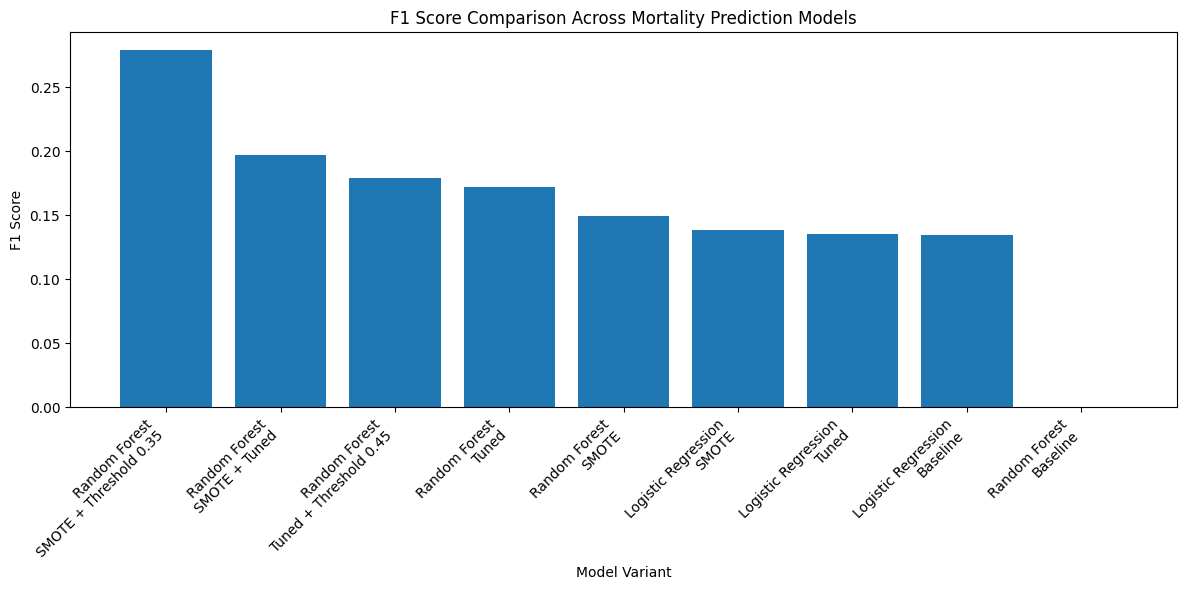

In [30]:
import matplotlib.pyplot as plt

plot_df = results_df.copy()

plot_df["Model_Name"] = (
    plot_df["Model"] + "\n" + plot_df["Sampling"]
)

plt.figure(figsize=(12,6))

plt.bar(
    plot_df["Model_Name"],
    plot_df["F1"]
)

plt.ylabel("F1 Score")
plt.xlabel("Model Variant")
plt.title("F1 Score Comparison Across Mortality Prediction Models")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

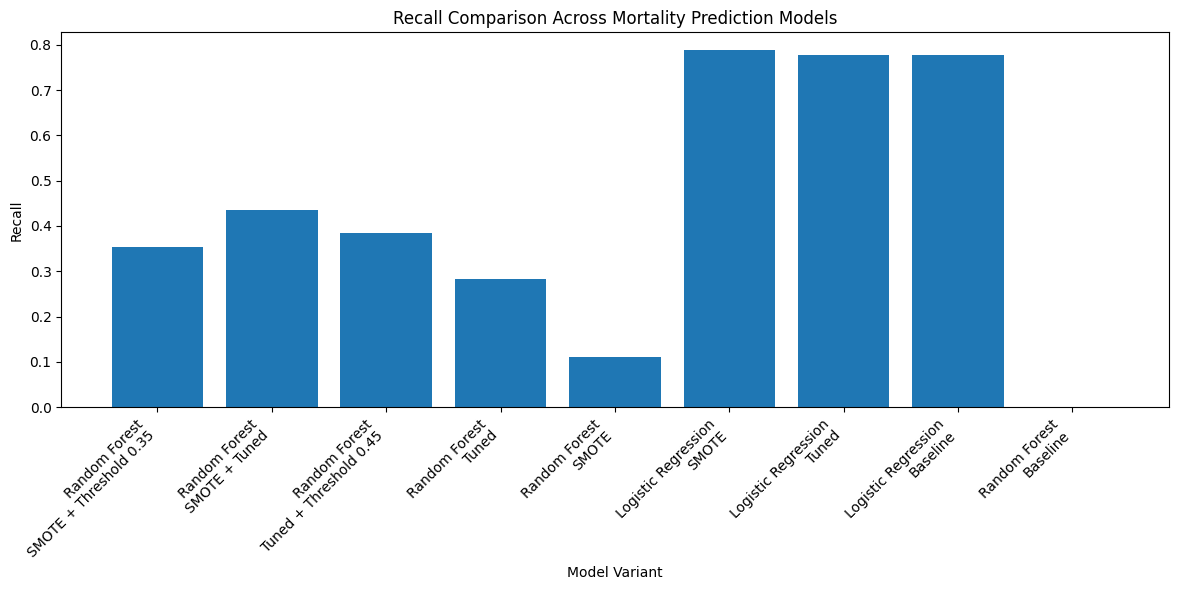

In [31]:
plt.figure(figsize=(12,6))

plt.bar(
    plot_df["Model_Name"],
    plot_df["Recall"]
)

plt.ylabel("Recall")
plt.xlabel("Model Variant")
plt.title("Recall Comparison Across Mortality Prediction Models")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

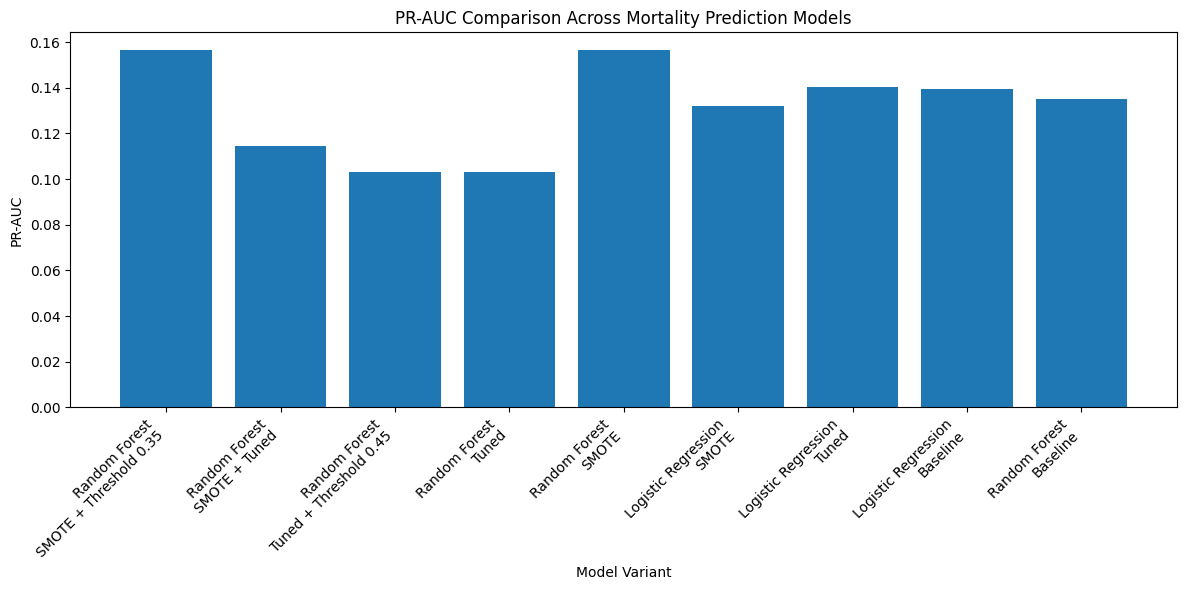

In [32]:
plt.figure(figsize=(12,6))

plt.bar(
    plot_df["Model_Name"],
    plot_df["PR_AUC"]
)

plt.ylabel("PR-AUC")
plt.xlabel("Model Variant")
plt.title("PR-AUC Comparison Across Mortality Prediction Models")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

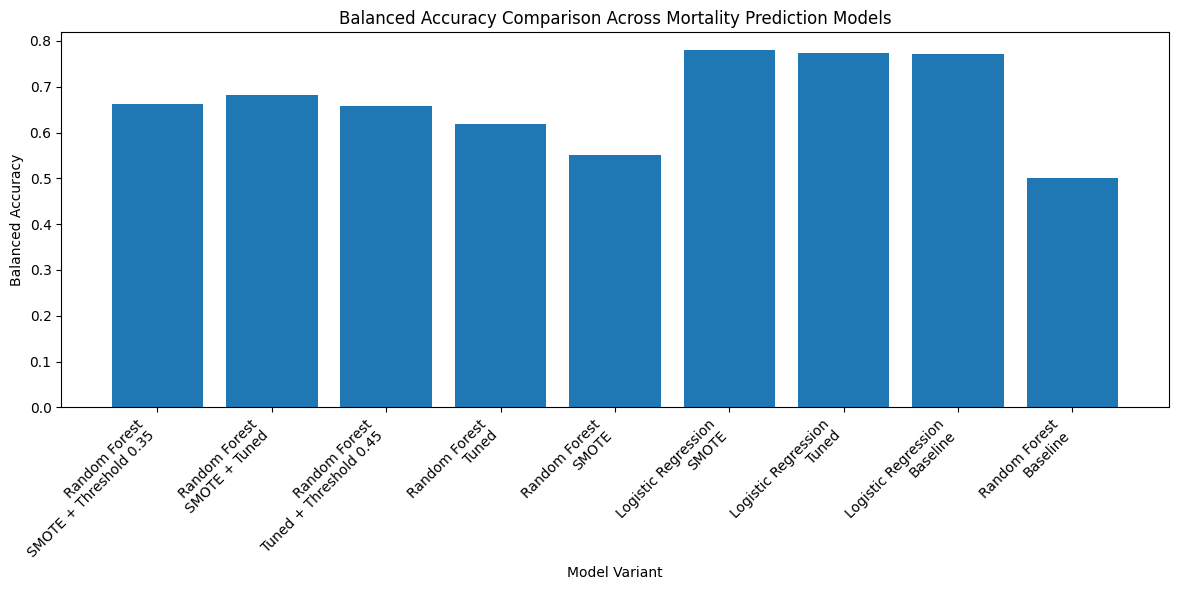

In [33]:
plt.figure(figsize=(12,6))

plt.bar(
    plot_df["Model_Name"],
    plot_df["Balanced_Accuracy"]
)

plt.ylabel("Balanced Accuracy")
plt.xlabel("Model Variant")
plt.title("Balanced Accuracy Comparison Across Mortality Prediction Models")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

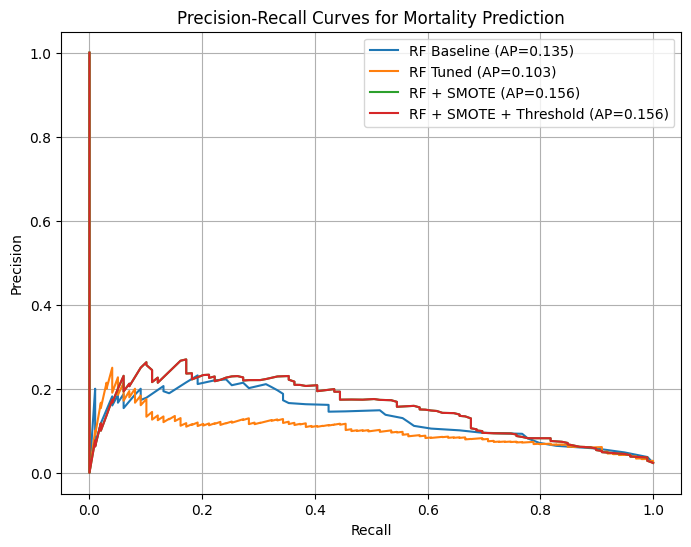

In [34]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

plt.figure(figsize=(8,6))

models = {
    "RF Baseline": y_prob_rf,
    "RF Tuned": y_prob_rf_tuned,
    "RF + SMOTE": y_prob_rf_smote,
    "RF + SMOTE + Threshold": y_prob_rf_smote
}

for name, probs in models.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        probs
    )

    ap = average_precision_score(
        y_test,
        probs
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} (AP={ap:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves for Mortality Prediction")

plt.legend()

plt.grid(True)

plt.show()

In [35]:
best_threshold = 0.35

y_pred_best = (y_prob_rf_smote >= best_threshold).astype(int)

print("\nBEST MODEL: Random Forest + SMOTE + Threshold 0.35")
print("=" * 60)
print(classification_report(y_test, y_pred_best, digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_smote))
print("PR-AUC:", average_precision_score(y_test, y_prob_rf_smote))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_best))
print("MCC:", matthews_corrcoef(y_test, y_pred_best))


BEST MODEL: Random Forest + SMOTE + Threshold 0.35
              precision    recall  f1-score   support

           0     0.9844    0.9718    0.9780      4146
           1     0.2303    0.3535    0.2789        99

    accuracy                         0.9574      4245
   macro avg     0.6073    0.6627    0.6285      4245
weighted avg     0.9668    0.9574    0.9617      4245

Confusion Matrix:
[[4029  117]
 [  64   35]]
ROC-AUC: 0.8708210907921472
PR-AUC: 0.1564684688081776
Balanced Accuracy: 0.6626576912394568
MCC: 0.2642373341566916


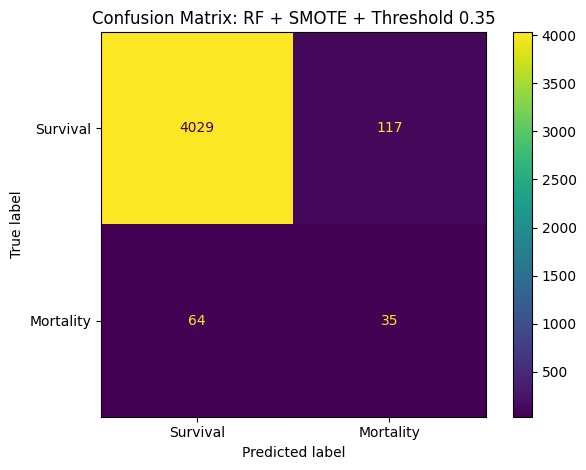

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Survival", "Mortality"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix: RF + SMOTE + Threshold 0.35")
plt.tight_layout()
plt.show()

Existing Visualizations

<Figure size 700x500 with 0 Axes>

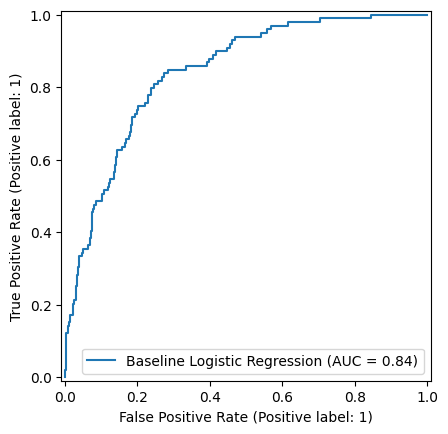

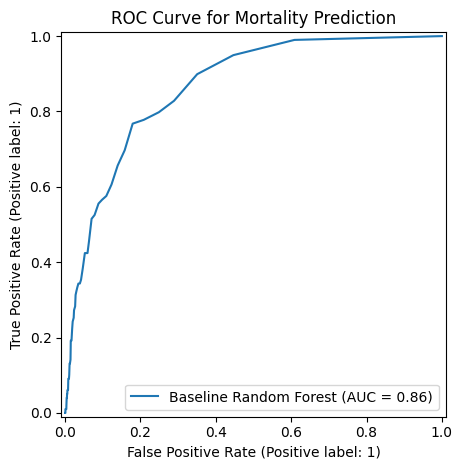

In [64]:

# --------------------------------------------------
# Step 11: ROC Curves (baseline models)
# --------------------------------------------------
plt.figure(figsize=(7, 5))

RocCurveDisplay.from_predictions(y_test, y_prob_lr, name="Baseline Logistic Regression")
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name="Baseline Random Forest")

plt.title("ROC Curve for Mortality Prediction")
plt.tight_layout()
plt.show()


<Figure size 700x500 with 0 Axes>

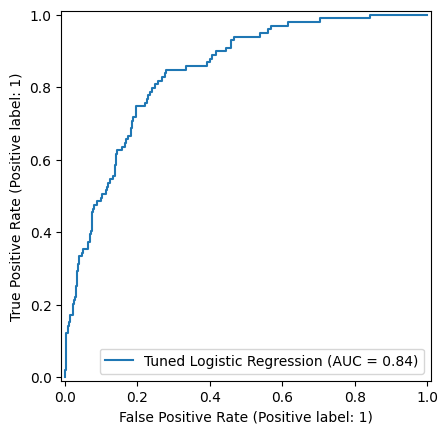

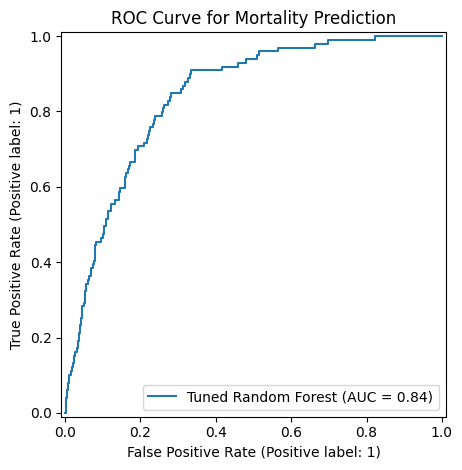

In [65]:

# --------------------------------------------------
# Step 11: ROC Curves (tune models)
# --------------------------------------------------
plt.figure(figsize=(7, 5))

RocCurveDisplay.from_predictions(y_test, y_prob_lr_tuned, name="Tuned Logistic Regression")
RocCurveDisplay.from_predictions(y_test, y_prob_rf_tuned, name="Tuned Random Forest")

plt.title("ROC Curve for Mortality Prediction")
plt.tight_layout()
plt.show()



Top 15 Important Features:
                             feature  importance
6                      num__SV7_mean    0.062044
2                      num__SV3_mean    0.057876
27                   num__SV7_median    0.056150
23                   num__SV3_median    0.053443
16                      num__SV3_max    0.042942
9                       num__SV3_min    0.041736
0                      num__SV1_mean    0.035714
55  cat__ICD_CATEGORY_Nervous system    0.032902
13                      num__SV7_min    0.030463
3                      num__SV4_mean    0.029355
21                   num__SV1_median    0.028987
24                   num__SV4_median    0.028223
8                       num__SV2_min    0.028149
5                      num__SV6_mean    0.025698
14                      num__SV1_max    0.025661


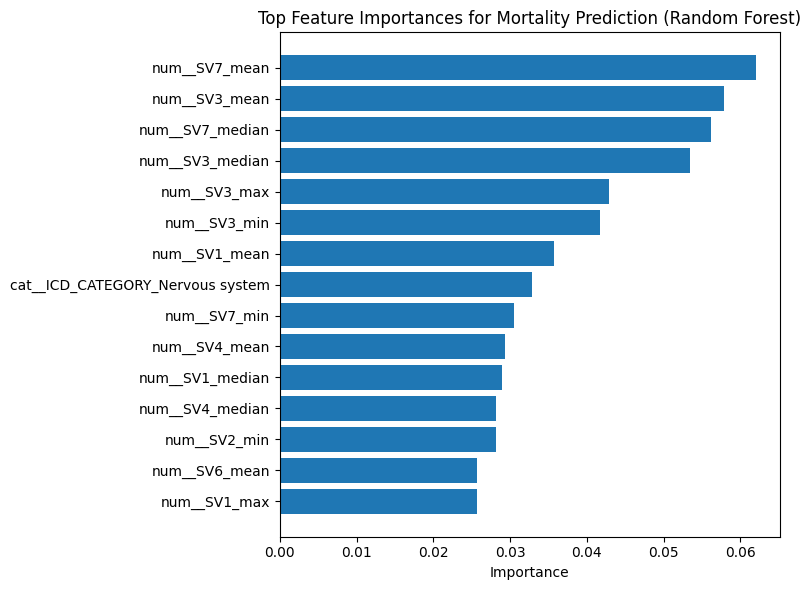

In [61]:

# --------------------------------------------------
# Step 12: Random Forest feature importance
# --------------------------------------------------
# Extract fitted preprocessing and model
fitted_preprocessor = best_rf.named_steps["preprocessor"]
fitted_model = best_rf.named_steps["model"]

# Get expanded feature names after preprocessing
feature_names = fitted_preprocessor.get_feature_names_out()

# Feature importances
importances = fitted_model.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\nTop 15 Important Features:")
print(importance_df.head(15))

# Plot top 15
top_n = 15
top_importance = importance_df.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(top_importance["feature"], top_importance["importance"])
plt.title("Top Feature Importances for Mortality Prediction (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [43]:
importance_df[importance_df["feature"].str.contains("ICD|PAIN|ANEMIA", case=False, na=False)]

,feature,importance
55,cat__ICD_CATEGORY_Nervous system,2.622775e-02
45,cat__ICD_CATEGORY_Digestive,1.302500e-02
44,cat__ICD_CATEGORY_Congenital,1.027259e-02
57,cat__ICD_CATEGORY_Perinatal,7.099801e-03
56,cat__ICD_CATEGORY_Other,4.605248e-03
51,cat__ICD_CATEGORY_Injury,4.507082e-03
43,cat__ICD_CATEGORY_Circulatory,3.692261e-03
58,cat__ICD_CATEGORY_Respiratory,3.632244e-03
60,cat__ICD_CATEGORY_Symptoms,3.129410e-03
42,cat__ICD_CATEGORY_Blood/Immune,2.207327e-03


In [ ]:

# --------------------------------------------------
# Step 13: Save model-ready predictions (optional)
# --------------------------------------------------
results_df = X_test.copy()
results_df["actual"] = y_test.values
results_df["pred_lr"] = y_pred_lr
results_df["prob_lr"] = y_prob_lr
results_df["pred_rf"] = y_pred_rf
results_df["prob_rf"] = y_prob_rf

results_df.to_csv("model_output/mortality_prediction_results.csv", index=False)
importance_df.to_csv("model_output/mortality_feature_importance.csv", index=False)


Model Reliability & Interpretability Analysis

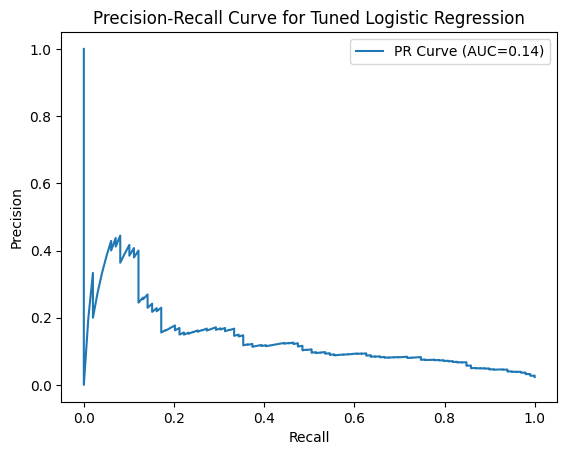

In [19]:
precision, recall, _ = precision_recall_curve(y_test, y_prob_lr_tuned)
pr_auc = auc(recall, precision)

plt.figure()
plt.plot(recall, precision, label=f"PR Curve (AUC={pr_auc:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Tuned Logistic Regression")
plt.legend()
plt.show()

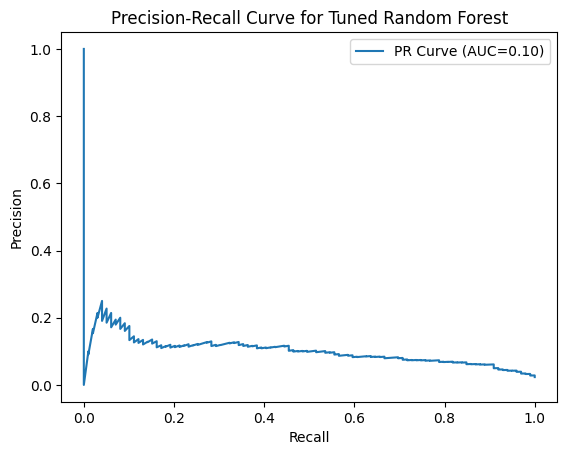

In [20]:
precision, recall, _ = precision_recall_curve(y_test, y_prob_rf_tuned)
pr_auc = auc(recall, precision)

plt.figure()
plt.plot(recall, precision, label=f"PR Curve (AUC={pr_auc:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Tuned Random Forest")
plt.legend()
plt.show()

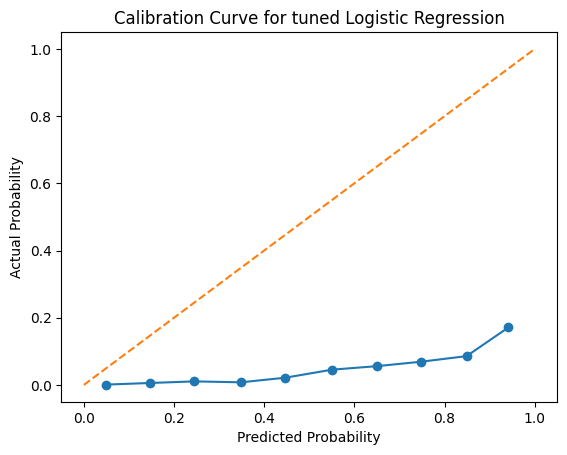

In [24]:
prob_true, prob_pred = calibration_curve(y_test, y_prob_lr_tuned, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.title("Calibration Curve for tuned Logistic Regression")
plt.show()

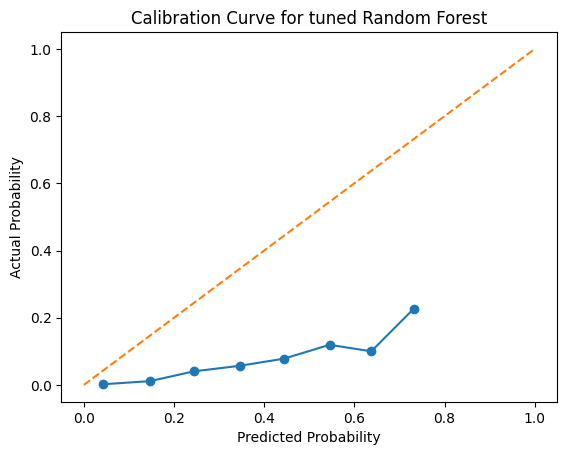

In [23]:
prob_true, prob_pred = calibration_curve(y_test, y_prob_rf_tuned, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.title("Calibration Curve for tuned Random Forest")
plt.show()

In [68]:
def clean_feature_name(feature_name):

    name = feature_name.replace("num__", "").replace("cat__", "")

    sv_mapping = {

        "SV1": "Heart Rate",

        "SV2": "Pulse",

        "SV3": "Systolic BP",

        "SV4": "Diastolic BP",

        "SV5": "Central Venous Pressure",

        "SV6": "Respiratory Rate",

        "SV7": "Oxygen Saturation"

    }

    stat_mapping = {

        "mean": "Mean",

        "median": "Median",

        "min": "Min",

        "max": "Max",

        "range": "Range"

    }

    for sv, clinical_name in sv_mapping.items():

        if name.startswith(sv + "_"):

            stat = name.replace(sv + "_", "")

            stat = stat_mapping.get(stat, stat)

            return f"{clinical_name} ({stat})"

    if name.startswith("ICD_CATEGORY_"):

        diagnosis = name.replace("ICD_CATEGORY_", "")

        return f"{diagnosis} Diagnosis"

    return name

In [71]:
def run_shap_analysis(model_pipeline, X_test, model_name, max_display=15, sample_size=500):

    # Extract components

    preprocessor = model_pipeline.named_steps["preprocessor"]

    model = model_pipeline.named_steps["model"]

    # Transform test data

    X_transformed = preprocessor.transform(X_test)

    if hasattr(X_transformed, "toarray"):

        X_transformed = X_transformed.toarray()

    # Get original transformed feature names

    feature_names = preprocessor.get_feature_names_out()

    # Convert SV feature names to clinical names

    clean_feature_names = [clean_feature_name(col) for col in feature_names]

    X_df = pd.DataFrame(

        X_transformed,

        columns=clean_feature_names

    )

    # Sample for speed

    X_sample = X_df.sample(

        n=min(sample_size, len(X_df)),

        random_state=42

    )

    # Random Forest SHAP

    if "RandomForest" in str(type(model)):

        explainer = shap.TreeExplainer(model)

        shap_values = explainer.shap_values(X_sample)

        # Correct class-1 extraction

        if isinstance(shap_values, list):

            shap_values_plot = shap_values[1]

        elif len(np.array(shap_values).shape) == 3:

            shap_values_plot = shap_values[:, :, 1]

        else:

            shap_values_plot = shap_values

    # Logistic Regression SHAP

    else:

        explainer = shap.LinearExplainer(model, X_sample)

        shap_values_plot = explainer.shap_values(X_sample)

    # Summary plot

    shap.summary_plot(

        shap_values_plot,

        X_sample,

        max_display=max_display,

        show=False

    )

    plt.title(f"SHAP Summary Plot - {model_name}")

    plt.tight_layout()

    plt.show()

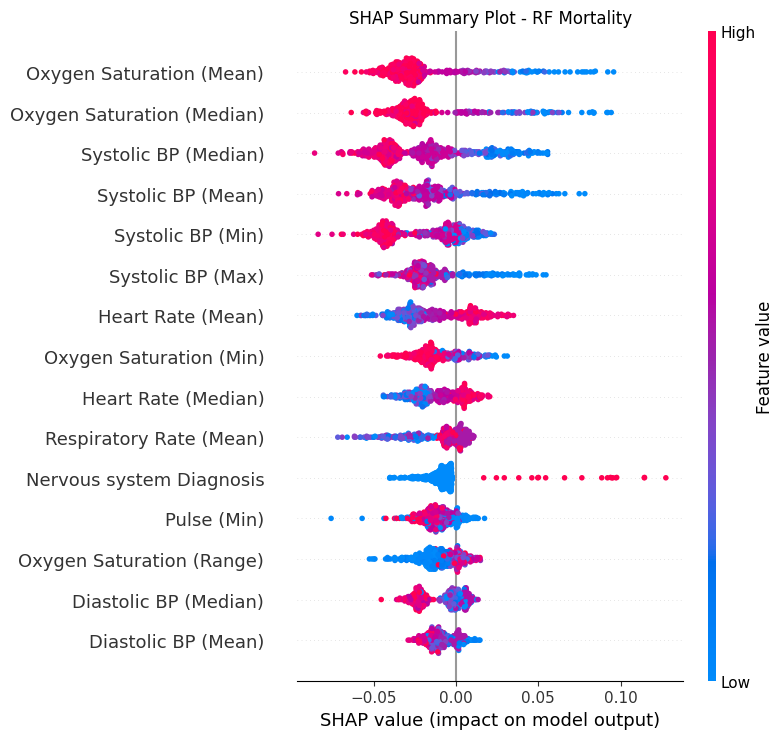

In [72]:
run_shap_analysis(best_rf, X_test, "RF Mortality")


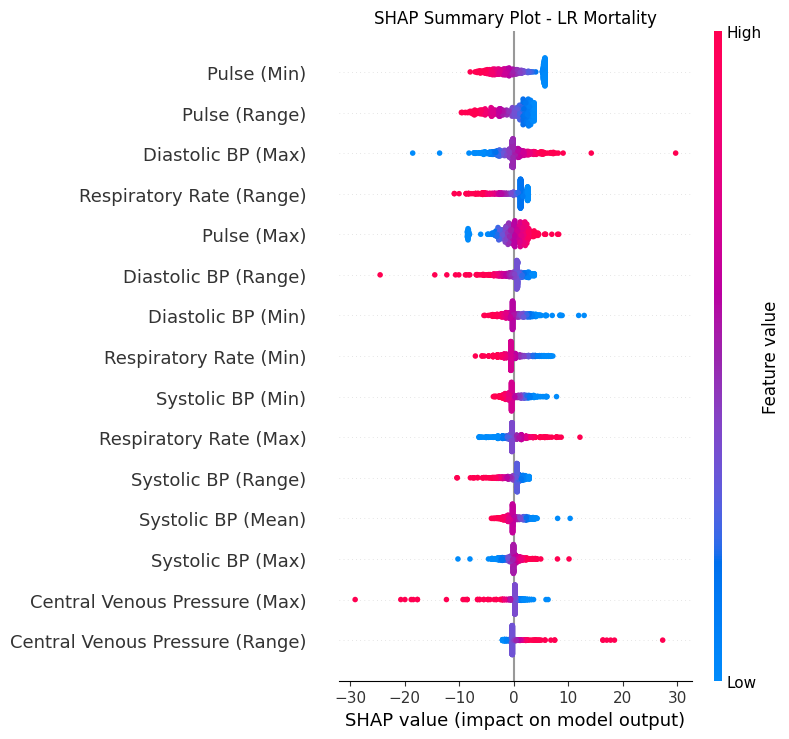

In [73]:
run_shap_analysis(best_lr, X_test, "LR Mortality")

Phase 2: SHAP Interpretability Analysis

In [74]:
# Extract fitted preprocessor and RF model from SMOTE pipeline

best_pipeline = rf_smote_pipeline

preprocessor_fitted = best_pipeline.named_steps["preprocessor"]
rf_model_fitted = best_pipeline.named_steps["model"]

X_test_processed = preprocessor_fitted.transform(X_test)

In [75]:
# Get feature names after preprocessing
try:
    feature_names = preprocessor_fitted.get_feature_names_out()
except:
    feature_names = [f"feature_{i}" for i in range(X_test_processed.shape[1])]


def clean_feature_name(name):
    # Remove sklearn transformer prefixes
    name = name.replace("num__", "").replace("cat__", "")

    sv_mapping = {
        "SV1": "Heart Rate",
        "SV2": "Pulse",
        "SV3": "Systolic BP",
        "SV4": "Diastolic BP",
        "SV5": "Central Venous Pressure",
        "SV6": "Respiratory Rate",
        "SV7": "Oxygen Saturation"
    }

    stat_mapping = {
        "mean": "Mean",
        "median": "Median",
        "min": "Min",
        "max": "Max",
        "range": "Range"
    }

    for sv, clinical_name in sv_mapping.items():
        if name.startswith(sv + "_"):
            stat = name.replace(sv + "_", "")
            stat = stat_mapping.get(stat, stat)
            return f"{clinical_name} ({stat})"

    if name.startswith("ICD_CATEGORY_"):
        diagnosis = name.replace("ICD_CATEGORY_", "")
        return f"{diagnosis} Diagnosis"

    return name


feature_names_cleaned = [
    clean_feature_name(name)
    for name in feature_names
]

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names_cleaned
)

X_test_processed_df.head()

,Heart Rate (Mean),Pulse (Mean),Systolic BP (Mean),Diastolic BP (Mean),Central Venous Pressure (Mean),Respiratory Rate (Mean),Oxygen Saturation (Mean),Heart Rate (Min),Pulse (Min),Systolic BP (Min),...,Mental Diagnosis,Musculoskeletal Diagnosis,Neoplasms Diagnosis,Nervous system Diagnosis,Other Diagnosis,Perinatal Diagnosis,Respiratory Diagnosis,Skin Diagnosis,Symptoms Diagnosis,Unknown Diagnosis
0,-1.108859,-0.307839,0.809174,0.953050,-0.101940,-0.002008,0.598716,-0.348863,0.136427,1.180953,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.187266,1.383198,-1.025025,-0.283495,-0.015538,-0.008327,0.120618,0.027697,0.636225,-1.463099,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.222795,-2.043272,-0.795589,-0.133642,-0.101940,-0.002008,0.498469,0.259426,-1.508743,-0.323422,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-0.228316,0.087423,0.063925,-0.328451,0.146394,0.201095,0.272915,-0.059201,0.365501,-0.961641,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.465067,-0.004232,0.140383,0.027153,-0.101940,-0.266910,-0.893842,0.056663,0.303026,0.223624,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [76]:
# SHAP explainer for Random Forest

explainer = shap.TreeExplainer(rf_model_fitted)

shap_values = explainer.shap_values(X_test_processed_df)

In [77]:
# =====================================================
# Correct SHAP values for binary classification
# Select class 1 = Mortality
# =====================================================

if isinstance(shap_values, list):
    shap_values_mortality = shap_values[1]

elif len(np.array(shap_values).shape) == 3:
    shap_values_mortality = shap_values[:, :, 1]

else:
    shap_values_mortality = shap_values

print("Mortality SHAP shape:", shap_values_mortality.shape)
print("X_test shape:", X_test_processed_df.shape)

Mortality SHAP shape: (4245, 62)
X_test shape: (4245, 62)


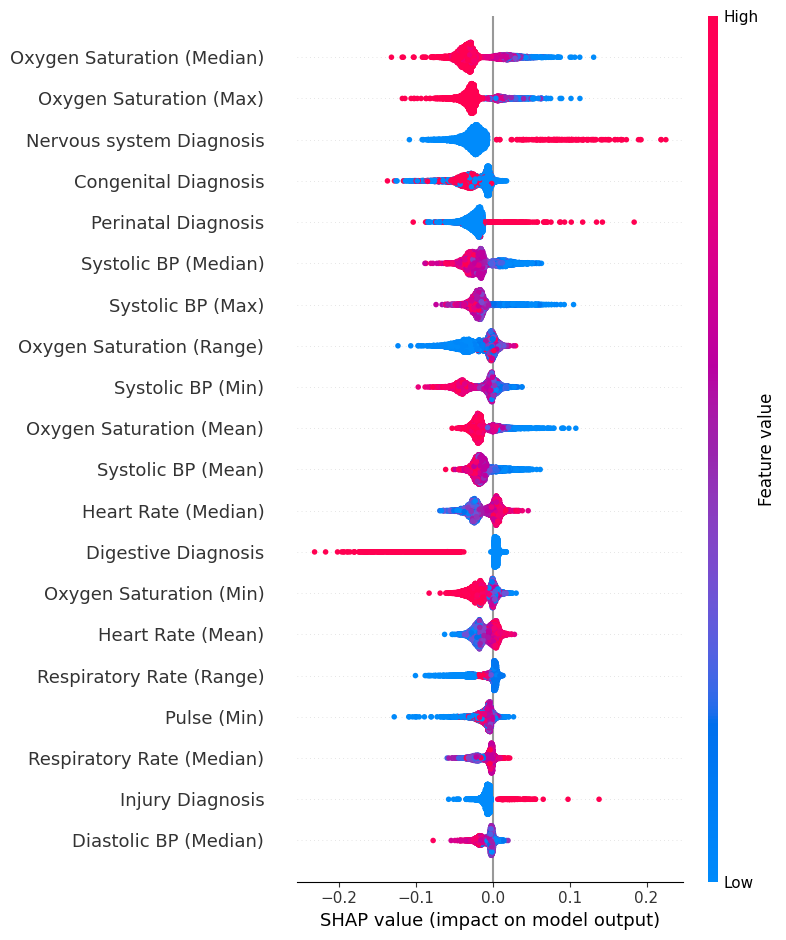

In [78]:
# SHAP Summary Plot for mortality class

shap.summary_plot(
    shap_values_mortality,
    X_test_processed_df,
    show=True
)

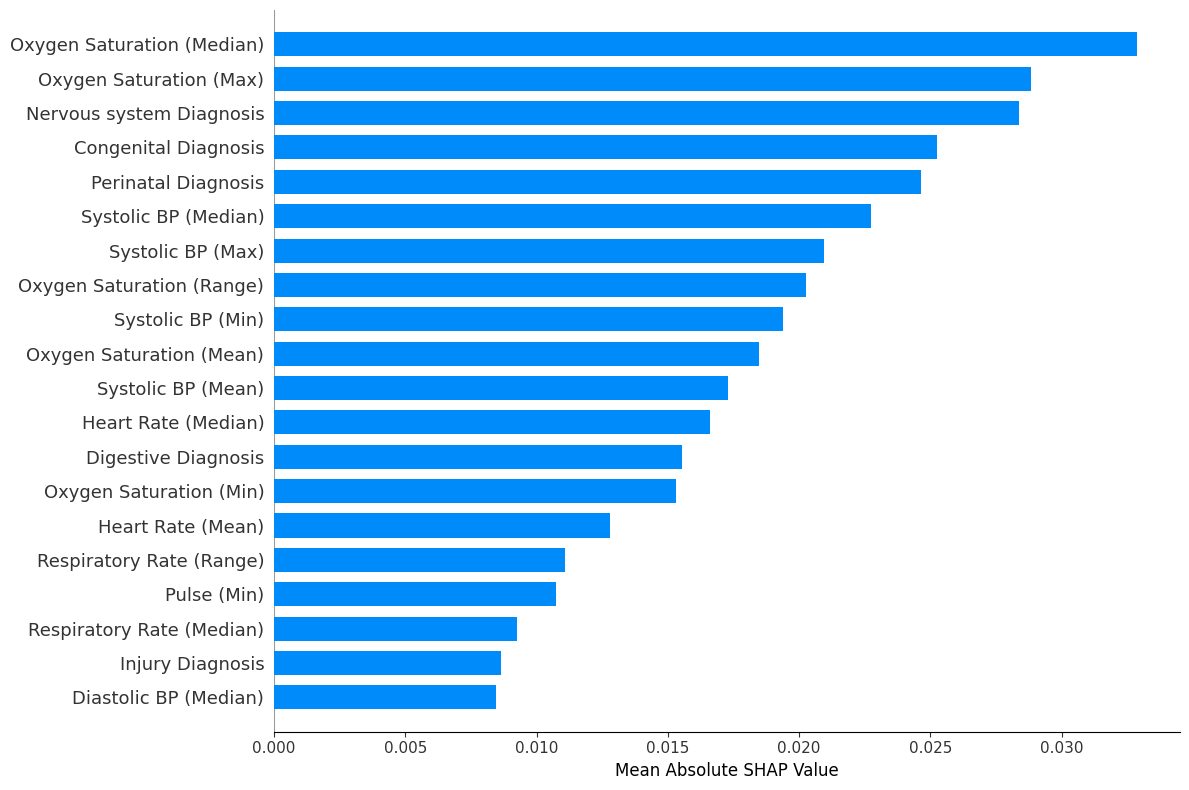

In [79]:
shap.summary_plot(
    shap_values_mortality,
    X_test_processed_df,
    plot_type="bar",
    show=False
)

plt.gcf().set_size_inches(12,8)

plt.xlabel(
    "Mean Absolute SHAP Value",
    fontsize=12
)

plt.tight_layout()

plt.show()

In [80]:
shap_importance = pd.DataFrame({
    "Feature": X_test_processed_df.columns,
    "Mean_ABS_SHAP": np.abs(shap_values_mortality).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="Mean_ABS_SHAP",
    ascending=False
).reset_index(drop=True)

display(shap_importance.head(20))

,Feature,Mean_ABS_SHAP
0,Oxygen Saturation (Median),0.032864
1,Oxygen Saturation (Max),0.028835
2,Nervous system Diagnosis,0.028377
3,Congenital Diagnosis,0.025263
4,Perinatal Diagnosis,0.024646
5,Systolic BP (Median),0.022745
6,Systolic BP (Max),0.020928
7,Oxygen Saturation (Range),0.020253
8,Systolic BP (Min),0.019381
9,Oxygen Saturation (Mean),0.018487
